## BIG DATA ANALYTICS 3:1 ##
## PRACTICAL ON CLUSTERING MINING TECHNIQUES: UNSUPERVISED MACHINE LEARNING

**K-MEANS CLUSTERING EXAMPLE**

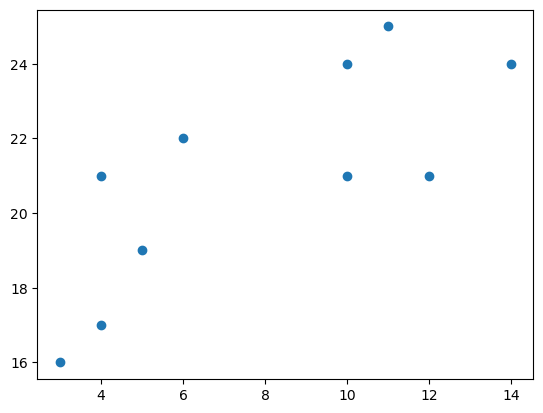

In [12]:
#Import a visual library
import matplotlib.pyplot as plt
#Generate random variables
x = [4, 5, 10, 4, 3, 11, 14 , 6, 10, 12]
y = [21, 19, 24, 17, 16, 25, 24, 22, 21, 21]
#Plot the variables
plt.scatter(x, y)
plt.show()

c:\Users\HP\miniconda3\envs\ML\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HP\miniconda3\envs\ML\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HP\miniconda3\envs\ML\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HP\miniconda3\envs\ML\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have

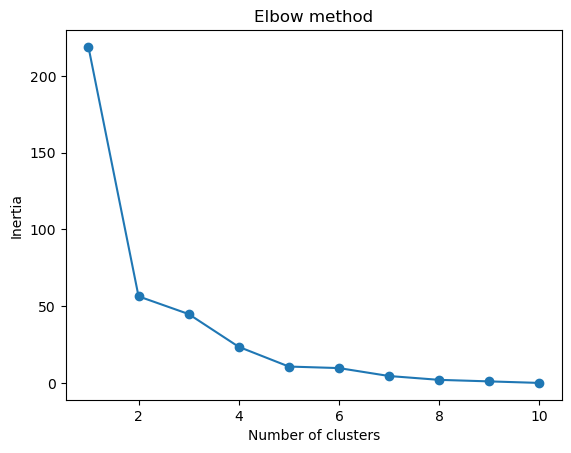

In [13]:
#Import KMeans clustering
from sklearn.cluster import KMeans
#Zip the variables in to a dataframe called data
data = list(zip(x, y))
inertias = []

#Cluster the data
for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

#Plot the Cluster plot using an elbow method to determine number of K (clusters)
plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

We plotted 10 possible clusters (K) but where the elbow bends are our most suitable number of clusters

In this case, K=2 or 3 or 4

Let's test the number of clusters

c:\Users\HP\miniconda3\envs\ML\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


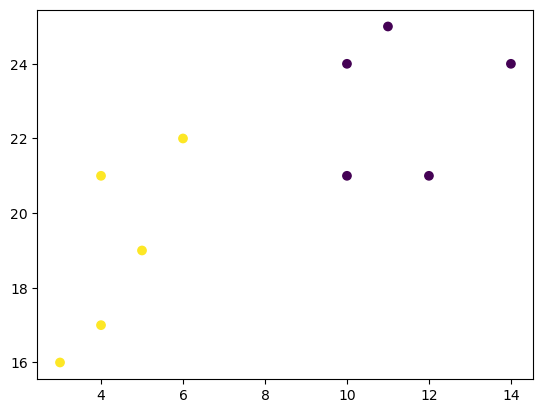

In [14]:
#Fit the data to K=2
kmeans = KMeans(n_clusters=2)
kmeans.fit(data)

plt.scatter(x, y, c=kmeans.labels_)
plt.show()

In [15]:
kmeans.inertia_

56.4

c:\Users\HP\miniconda3\envs\ML\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


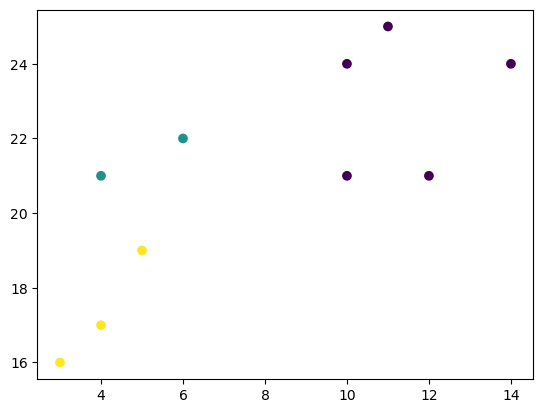

In [16]:
#Fit the data to K=3
kmeans = KMeans(n_clusters=3)
kmeans.fit(data)

plt.scatter(x, y, c=kmeans.labels_)
plt.show()

In [17]:
kmeans.inertia_

34.36666666666667

c:\Users\HP\miniconda3\envs\ML\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


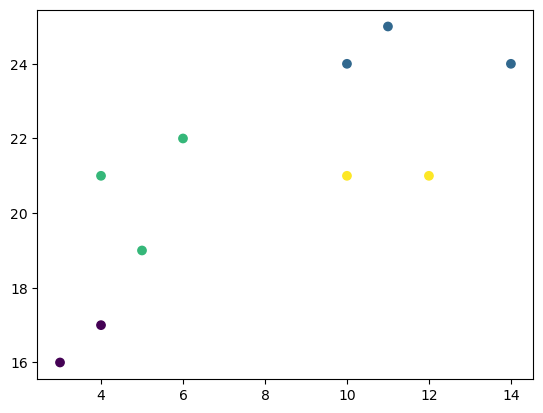

In [18]:
#Fit data to K=4
kmeans = KMeans(n_clusters=4)
kmeans.fit(data)

plt.scatter(x, y, c=kmeans.labels_)
plt.show()

In [19]:
kmeans.inertia_

19.0

Based on the intertia, K=4 is the most suitable number of clusters (lowest intertia value)

**HIERIACHICAL CLUSTERING EXAMPLE**

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

x = [4, 5, 10, 4, 3, 11, 14 , 6, 10, 12]
y = [21, 19, 24, 17, 16, 25, 24, 22, 21, 21]

data2 = list(zip(x, y))
#view data2
data2

[(4, 21),
 (5, 19),
 (10, 24),
 (4, 17),
 (3, 16),
 (11, 25),
 (14, 24),
 (6, 22),
 (10, 21),
 (12, 21)]

In [21]:
#Calculate the linkage between all of the different points using euclidean distance
linkage_data = linkage(data2, method='ward', metric='euclidean')

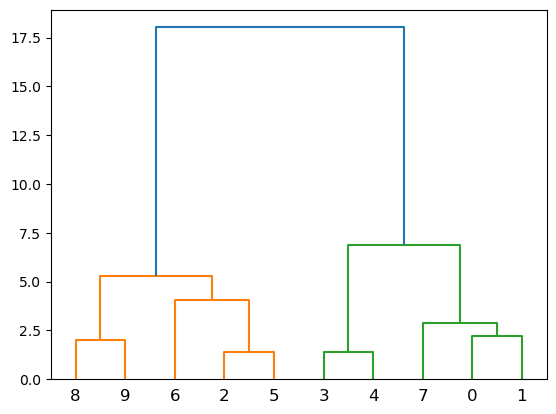

In [22]:
#View the dendogram
dendrogram(linkage_data)
plt.show()

We see two clusters, so let's use the hieriachical clustering method to fit these two clusters by first calculating the distance matrix

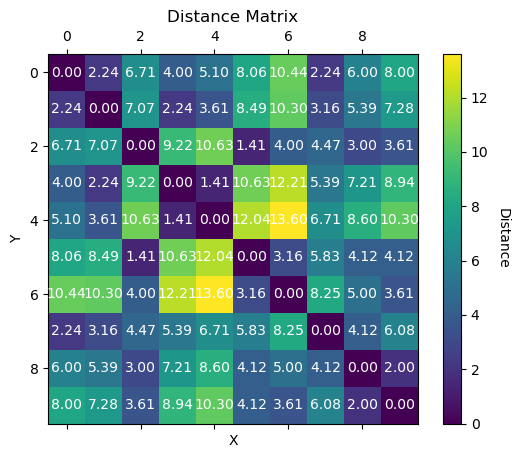

In [23]:
# Calculate distance matrix
distance_matrix = squareform(pdist(data2))

# Visualization distance matrix
fig, ax = plt.subplots()
cax = ax.matshow(distance_matrix, cmap='viridis')

# Distance values for matrix cells
for i in range(len(data2)):
    for j in range(len(data2)):
        ax.text(j, i, f'{distance_matrix[i, j]:.2f}', ha='center', va='center', color='white')

# Add color bar
cbar = fig.colorbar(cax)
cbar.ax.set_ylabel('Distance', rotation=270, labelpad=15)

# Show chart
plt.title('Distance Matrix')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_15084\966024749.py:2: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='single')


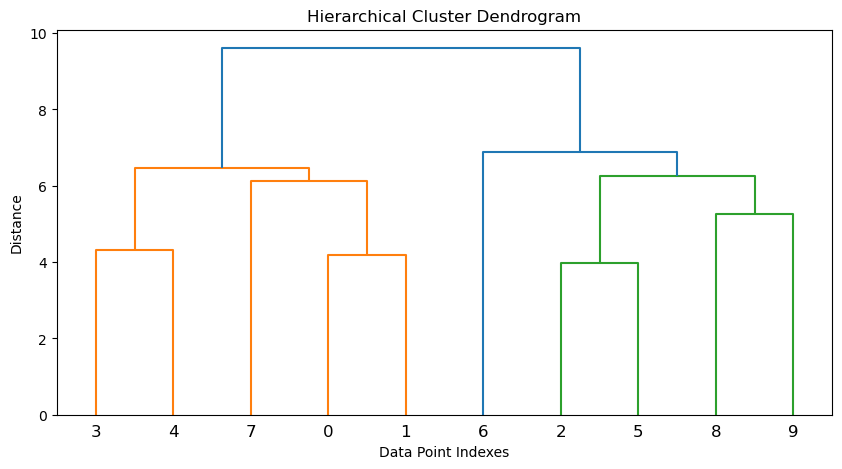

In [24]:
#Use the distance matrix to generate the dendogram
Z = linkage(distance_matrix, method='single')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Hierarchical Cluster Dendrogram')
plt.xlabel('Data Point Indexes')
plt.ylabel('Distance')
plt.show()

**REAL LIFE EXAMPLE OF CLUSTERING: MALL_CUSTOMER DATA**

Each customer’s customerID, genre, age, annual income, and spending score are all included in the data frame. The amount computed for each of their clients’ spending scores is based on several criteria, such as their income, the number of times per week they visit the mall, and the money they spent for a year. This score ranges from 1 to 100

* So the goal is to segment the customers based on the spending scores and the incomes (Columns 3 and 4)

In [25]:
#Import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#Import dataset
dataset = pd.read_csv('Mall_Customers.csv')
#Subset to only have the columns of interest
X = dataset.iloc[:, [3,4]].values
print(X)

[[ 15  39]
 [ 15  81]
 [ 16   6]
 [ 16  77]
 [ 17  40]
 [ 17  76]
 [ 18   6]
 [ 18  94]
 [ 19   3]
 [ 19  72]
 [ 19  14]
 [ 19  99]
 [ 20  15]
 [ 20  77]
 [ 20  13]
 [ 20  79]
 [ 21  35]
 [ 21  66]
 [ 23  29]
 [ 23  98]
 [ 24  35]
 [ 24  73]
 [ 25   5]
 [ 25  73]
 [ 28  14]
 [ 28  82]
 [ 28  32]
 [ 28  61]
 [ 29  31]
 [ 29  87]
 [ 30   4]
 [ 30  73]
 [ 33   4]
 [ 33  92]
 [ 33  14]
 [ 33  81]
 [ 34  17]
 [ 34  73]
 [ 37  26]
 [ 37  75]
 [ 38  35]
 [ 38  92]
 [ 39  36]
 [ 39  61]
 [ 39  28]
 [ 39  65]
 [ 40  55]
 [ 40  47]
 [ 40  42]
 [ 40  42]
 [ 42  52]
 [ 42  60]
 [ 43  54]
 [ 43  60]
 [ 43  45]
 [ 43  41]
 [ 44  50]
 [ 44  46]
 [ 46  51]
 [ 46  46]
 [ 46  56]
 [ 46  55]
 [ 47  52]
 [ 47  59]
 [ 48  51]
 [ 48  59]
 [ 48  50]
 [ 48  48]
 [ 48  59]
 [ 48  47]
 [ 49  55]
 [ 49  42]
 [ 50  49]
 [ 50  56]
 [ 54  47]
 [ 54  54]
 [ 54  53]
 [ 54  48]
 [ 54  52]
 [ 54  42]
 [ 54  51]
 [ 54  55]
 [ 54  41]
 [ 54  44]
 [ 54  57]
 [ 54  46]
 [ 57  58]
 [ 57  55]
 [ 58  60]
 [ 58  46]
 [ 59  55]

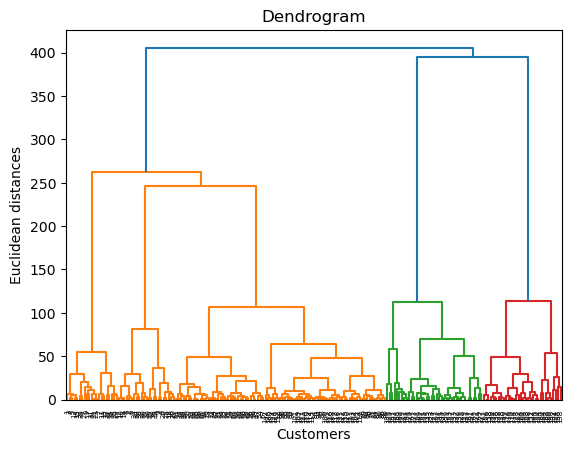

In [26]:
#Generate a dendogram of the dataset
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(X, method  = "ward"))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

Customers are represented on the x-axis, and the Euclidean distance between clusters is represented on the y-axis. 

How do we figure out the best number of clusters based on this diagram? We want to find the longest vertical distance we can without crossing any horizontal lines, which is the red-framed line in the diagram above. 

Let’s count the vertical lines on the diagram and figure out how many clusters are best.

There are 5 clusters (see vertical lines of each cluster)

One can also use the distance to set a threshold to help determine the number of clusters e.g. the red horizontal line
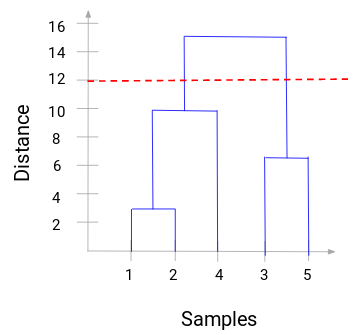

The above shows two clusters

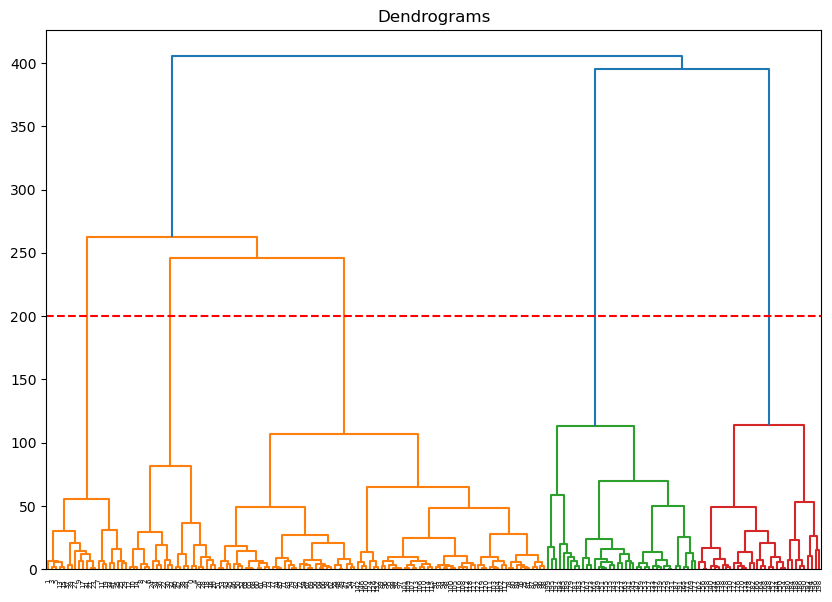

In [27]:
#Let's set our threshold distance at 200
plt.figure(figsize=(10, 7))  
plt.title("Dendrograms")  
dend = sch.dendrogram(sch.linkage(X, method='ward'))
plt.axhline(y=200, color='r', linestyle='--')

In [28]:
from sklearn.cluster import AgglomerativeClustering 
hc = AgglomerativeClustering(n_clusters = 5, metric = 'euclidean', linkage ='ward')
# Lets try to fit the hierarchical clustering algorithm  to dataset X while creating the 
# clusters vector that tells for each customer which cluster the customer belongs to.
y_hc=hc.fit_predict(X)

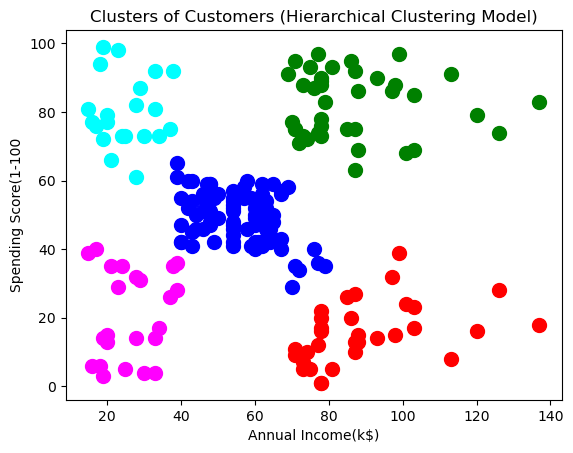

In [29]:
#Visualise the clusters
plt.scatter(X[y_hc==0, 0], X[y_hc==0, 1], s=100, c='red', label ='Cluster 1')
plt.scatter(X[y_hc==1, 0], X[y_hc==1, 1], s=100, c='blue', label ='Cluster 2')
plt.scatter(X[y_hc==2, 0], X[y_hc==2, 1], s=100, c='green', label ='Cluster 3')
plt.scatter(X[y_hc==3, 0], X[y_hc==3, 1], s=100, c='cyan', label ='Cluster 4')
plt.scatter(X[y_hc==4, 0], X[y_hc==4, 1], s=100, c='magenta', label ='Cluster 5')
plt.title('Clusters of Customers (Hierarchical Clustering Model)')
plt.xlabel('Annual Income(k$)')
plt.ylabel('Spending Score(1-100')
plt.show()

* Labels
* Cluster1(Red), Cluster2 (Blue), Cluster3(Green), Cluster4(Cyan), Cluster5 (Magenta)
* Cluster 1: High income, low spender
* Cluster 2: Moderate income, moderate spender
* Cluster 3: High income, high spender
* Cluster 4: Low income, high spender
* Low income, low spender

**SECOND EXAMPLE: IRIS DATASET**

* Goal: To cluster the flower species based on the variables SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
* Exclude the ID
* There are 3 flower species, let's search for atleast most five clusters

     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm         Species
0              5.1           3.5            1.4           0.2     Iris-setosa
1              4.9           3.0            1.4           0.2     Iris-setosa
2              4.7           3.2            1.3           0.2     Iris-setosa
3              4.6           3.1            1.5           0.2     Iris-setosa
4              5.0           3.6            1.4           0.2     Iris-setosa
..             ...           ...            ...           ...             ...
145            6.7           3.0            5.2           2.3  Iris-virginica
146            6.3           2.5            5.0           1.9  Iris-virginica
147            6.5           3.0            5.2           2.0  Iris-virginica
148            6.2           3.4            5.4           2.3  Iris-virginica
149            5.9           3.0            5.1           1.8  Iris-virginica

[150 rows x 5 columns]


c:\Users\HP\miniconda3\envs\ML\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HP\miniconda3\envs\ML\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HP\miniconda3\envs\ML\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HP\miniconda3\envs\ML\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have

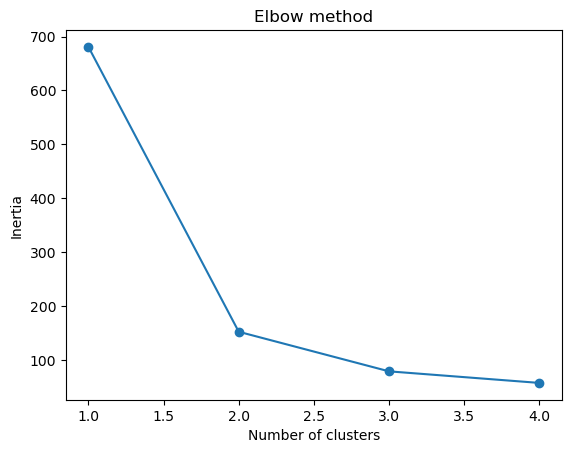

In [30]:
#Import dataset
import pandas as pd
data3=pd.read_csv("C:/Users/HP/Desktop/Big Data/Practical 6_Clustering_USL/Practical 6_Clustering_USL/Iris.csv")
#Subset to only have the columns of interest
data4 = data3[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm", "Species"]]
print(data4)

#Generate a dataframe with only the predictor features
features = data4.loc[:,["SepalLengthCm","SepalWidthCm","PetalLengthCm","PetalWidthCm"]]
#Import KMeans clustering
from sklearn.cluster import KMeans
inertias = []
#Cluster the feature data
for i in range(1,5):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(features)
    inertias.append(kmeans.inertia_)

#Plot the Cluster plot using an elbow method to determine number of K (clusters). We have 3 flower species
plt.plot(range(1,5), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

### Determining the Number of Clusters Using Dendrograms

The dendrogram helps visualize the hierarchical clustering process and decide the optimal number of clusters by looking for the largest vertical distance (gap) that can be cut without crossing any horizontal line.

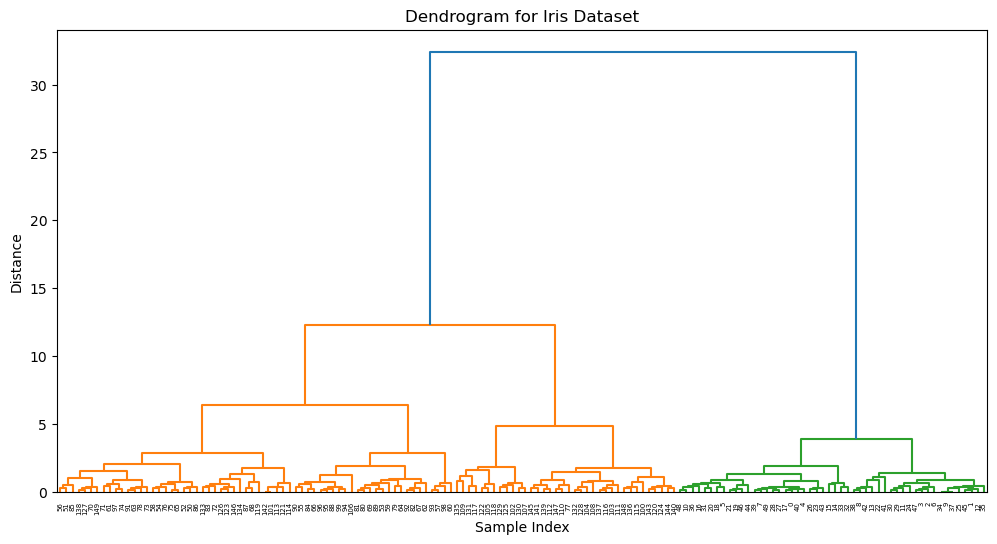

In [35]:
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Load the Iris dataset (if not already loaded)
iris = pd.read_csv('Iris.csv')
X = iris.drop(['Id', 'Species'], axis=1)

# Compute the linkage matrix
linked = linkage(X, method='ward')

# Plot the dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=False)
plt.title('Dendrogram for Iris Dataset')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

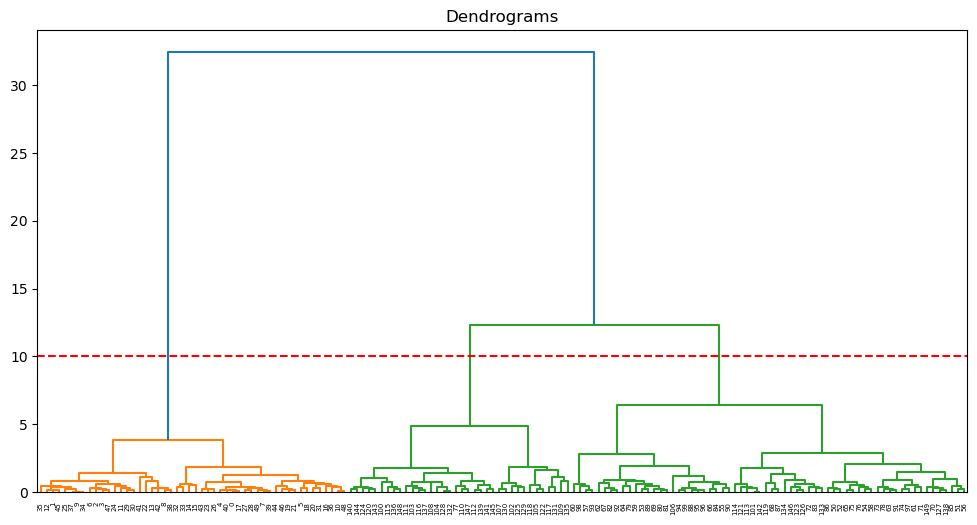

In [36]:
plt.figure(figsize=(12, 6))  
plt.title("Dendrograms")  
dend = sch.dendrogram(sch.linkage(X, method='ward'))
plt.axhline(y=10, color='r', linestyle='--')

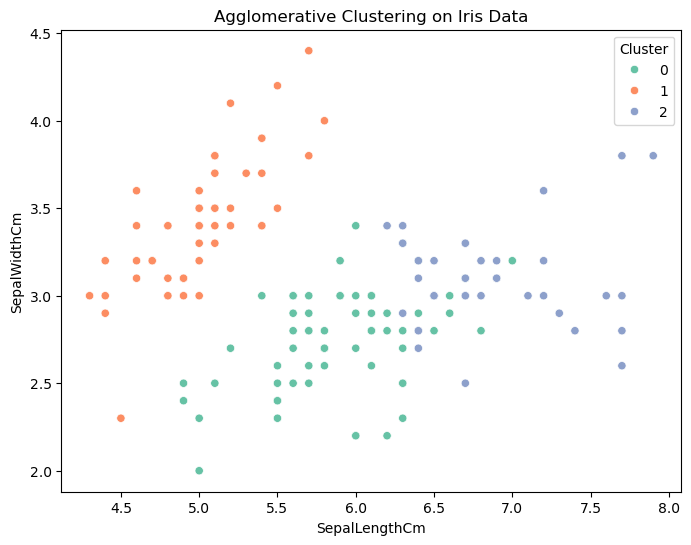

In [33]:
# Agglomerative (Hierarchical) Clustering
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Iris dataset if not already loaded
iris = pd.read_csv('Iris.csv')
X = iris.drop(['Id', 'Species'], axis=1)

agglo = AgglomerativeClustering(n_clusters=3)
iris['Agglo_Cluster'] = agglo.fit_predict(X)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X.iloc[:,0], y=X.iloc[:,1], hue=iris['Agglo_Cluster'], palette='Set2')
plt.title('Agglomerative Clustering on Iris Data')
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.legend(title='Cluster')
plt.show()

